# <center>**Stellar Classification Comparative Analysis**</center>

#### <center>**Brian Urban**</center>

#### <center>June 13, 2025</center>

<br>

### **1. Environment Setup and Reproducibility**

This section imports the core Python libraries used in this project:

- `pandas` for loading, exploring and manipulating tabular data.

- `scikit-learn` for preprocessing, dataset splitting, metrics, and baseline models.

- `matplotlib` and `seaborn` are used to plot training results and evaluation metrics.

- `torch` for implementing and training the neural network model.

In [1]:
# ============================================================
# IMPORTING LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

All random seeds are fixed for full reproducibility across experiments.

In [2]:
# ============================================================
# SET ALL SEEDS
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

<br>

### **2. Data Pipeline, Model Architecture, and Evaluation Framework**

The preprocessing pipeline separates numeric features (temperature, luminosity, radius, absolute magnitude) from categorical features (star color, spectral class) to enable targeted noise injection on continuous physical observables. Numeric features are standardized within each cross-validation fold to prevent data leakage, while categorical features are one-hot encoded once outside the CV loop, reflecting the assumption that spectral classifications remain reliable even when physical measurements carry uncertainty.

The experiment uses 5-fold stratified cross-validation rather than a single train/validation/test split, providing more reliable performance estimates on the 240-sample dataset. Four models are evaluated: a PyTorch MLP, logistic regression, an unconstrained decision tree, and a depth-constrained decision tree (max_depth=4).

The MLP architecture consists of two hidden layers (64 and 32 neurons) with ReLU activations, batch normalization, and dropout(0.3), followed by a 6-neuron output layer. Dropout was reduced from 0.5 to 0.3 based on preliminary experiments showing that aggressive regularization on a 240-sample dataset suppressed the model's ability to learn underlying patterns without meaningful overfitting protection.

In [3]:
# ============================================================
# LOAD AND PREPARE DATA (modified from original)
# ============================================================

df = pd.read_csv("hr-diagram.csv")
df = df.rename(columns={
    'Temperature (K)':         'Temperature',
    'Luminosity (L/Lo)':       'Luminosity',
    'Radius (R/Ro)':           'Radius',
    'Absolute Magnitude (Mv)': 'Absolute_Magnitude',
    'Star Color':              'Color',
    'Spectral Class':          'Spectral_Class',
    'Star Type':               'Star_Type'
})

# Clean whitespace in categorical columns
df['Color'] = df['Color'].str.strip()

# Separate numeric and categorical features
numeric_cols = ['Temperature', 'Luminosity', 'Radius', 'Absolute_Magnitude']
categorical_cols = ['Color', 'Spectral_Class']

# Raw numeric features as numpy array (targets for noise injection)
X_numeric_raw = df[numeric_cols].values.astype(float)

# One-hot encode ONLY the categorical columns, convert to numpy array
X_categorical = pd.get_dummies(df[categorical_cols]).values.astype(float)

# Target as numpy array
y_array = df['Star_Type'].values

# Sanity check—run this to verify before proceeding
print(f"X_numeric_raw: type={type(X_numeric_raw)}, shape={X_numeric_raw.shape}")
print(f"X_categorical: type={type(X_categorical)}, shape={X_categorical.shape}")
print(f"y_array:       type={type(y_array)}, shape={y_array.shape}")

X_numeric_raw: type=<class 'numpy.ndarray'>, shape=(240, 4)
X_categorical: type=<class 'numpy.ndarray'>, shape=(240, 17)
y_array:       type=<class 'numpy.ndarray'>, shape=(240,)


In [4]:
# ============================================================
# HELPER FUNCTION 1: NOISE INJECTION
# ============================================================

def add_gaussian_noise(X_numeric, noise_level, seed=42):
    """
    Add Gaussian noise proportional to each feature's standard deviation.
    Simulates measurement uncertainty on continuous physical observables.
    noise_level: fraction of feature std (0.1 = 10% of std as noise std)
    """
    rng = np.random.RandomState(seed)
    X_noisy = X_numeric.copy()
    for col in range(X_numeric.shape[1]):
        col_std = X_numeric[:, col].std()
        if col_std > 0:
            noise = rng.normal(0, noise_level * col_std, size=X_numeric.shape[0])
            X_noisy[:, col] += noise
    return X_noisy

In [5]:
# ============================================================
# HELPER FUNCTION 2: MLP TRAIN/EVAL
# ============================================================

def train_eval_mlp(X_train, y_train, X_test, y_test, dropout=0.3,
                   lr=0.001, epochs=50, batch_size=32, seed=42):
    """
    Train a regulated MLP and return (accuracy, marco_f1).
    Dropout reduced to 0.3 from original 0.5—less aggressive on 240 samples
    """
    torch.manual_seed(seed)

    input_dim = X_train.shape[1]

    model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),
            nn.Linear(32, 6)  # 6 star types
        )
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_model_state = None
    best_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            train_loss = criterion(model(X_train_t), y_train_t).item()
        if train_loss < best_loss:
            best_loss = train_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1).numpy()
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    return acc, f1

In [6]:
# ============================================================
# HELPER FUNCTION 3: CROSS-VALIDATED EVALUATION
# ============================================================

def evaluate_models_cv(X_numeric, X_categorical, y, noise_level=0.0,
                       n_folds=5, seed=42):
    """
    Evaluate MLP, Logistic Regression, and two Decision Tree variants
    across k stratified folds with optional Gaussian noise on numeric features.
    """
    # Safety: force numpy arrays in case DataFrames slipped through
    X_numeric = np.asarray(X_numeric, dtype=float)
    X_categorical = np.asarray(X_categorical, dtype=float)
    y = np.asarray(y)

    print(f"  Shapes — X_numeric: {X_numeric.shape}, "
          f"X_categorical: {X_categorical.shape}, y: {y.shape}")

    assert X_numeric.shape[0] == X_categorical.shape[0] == y.shape[0], \
        f"Row count mismatch! numeric={X_numeric.shape[0]}, " \
        f"categorical={X_categorical.shape[0]}, y={y.shape[0]}"

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    results = {
        'mlp': {'acc': [], 'f1': []},
        'logreg': {'acc': [], 'f1': []},
        'dtree_constrained': {'acc': [], 'f1': []},
        'dtree_full': {'acc': [], 'f1': []}
    }

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_numeric, y)):
        # --- Split features by fold indices ---
        X_num_train = X_numeric[train_idx].copy()
        X_num_test = X_numeric[test_idx].copy()
        X_cat_train = X_categorical[train_idx]
        X_cat_test = X_categorical[test_idx]

        y_train_fold = y[train_idx]
        y_test_fold = y[test_idx]

        # --- Inject noise into numeric features ONLY ---
        if noise_level > 0:
            X_num_train = add_gaussian_noise(X_num_train, noise_level, seed=fold)
            X_num_test = add_gaussian_noise(X_num_test, noise_level, seed=fold + 100)

        # --- Combine noisy numeric + clean categorical ---
        X_train_combined = np.hstack([X_num_train, X_cat_train])
        X_test_combined = np.hstack([X_num_test, X_cat_test])

        # --- Standardize within each fold (fit on train only) ---
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_combined)
        X_test_scaled = scaler_fold.transform(X_test_combined)

        # --- Logistic Regression ---
        lr = LogisticRegression(max_iter=1000, random_state=seed)
        lr.fit(X_train_scaled, y_train_fold)
        lr_preds = lr.predict(X_test_scaled)
        results['logreg']['acc'].append(accuracy_score(y_test_fold, lr_preds))
        results['logreg']['f1'].append(f1_score(y_test_fold, lr_preds, average='macro'))

        # --- Decision Tree (unconstrained) ---
        dt_full = DecisionTreeClassifier(random_state=seed)
        dt_full.fit(X_train_scaled, y_train_fold)
        dt_full_preds = dt_full.predict(X_test_scaled)
        results['dtree_full']['acc'].append(accuracy_score(y_test_fold, dt_full_preds))
        results['dtree_full']['f1'].append(f1_score(y_test_fold, dt_full_preds, average='macro'))

        # --- Decision Tree (constrained, max_depth=4) ---
        dt_constrained = DecisionTreeClassifier(max_depth=4, random_state=seed)
        dt_constrained.fit(X_train_scaled, y_train_fold)
        dt_c_preds = dt_constrained.predict(X_test_scaled)
        results['dtree_constrained']['acc'].append(accuracy_score(y_test_fold, dt_c_preds))
        results['dtree_constrained']['f1'].append(f1_score(y_test_fold, dt_c_preds, average='macro'))

        # --- MLP ---
        mlp_acc, mlp_f1 = train_eval_mlp(
            X_train_scaled, y_train_fold,
            X_test_scaled, y_test_fold,
            dropout=0.3, seed=seed
        )
        results['mlp']['acc'].append(mlp_acc)
        results['mlp']['f1'].append(mlp_f1)

    return results

<br>

### **3. Experiment 1: Noise Robustness Sweep**

The noise robustness sweep evaluates all four models across 5 stratified folds at six Gaussian noise levels (0.0, 0.1, 0.25, 0.5, 0.75, 1.0). Noise is injected into numeric features only, scaled proportionally to each feature's standard deviation, simulating realistic measurement uncertainty on continuous physical observables. Training and test sets receive independent noise injections per fold.

The MLP is trained for 50 epochs per fold using the Adam optimizer (lr=0.001) with cross-entropy loss and mini-batch stochastic gradient descent (batch size=32). The best model state is selected by lowest training loss within each fold. Results are reported as mean ± standard deviation across the 5 folds.

In [7]:
# ============================================================
# EXPERIMENT 1: NOISE ROBUSTNESS SWEEP
# ============================================================

noise_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
all_results = {}

for noise in noise_levels:
    print(f"\n{'='*70}")
    print(f"NOISE LEVEL: {noise}")
    print(f"{'='*70}")
    all_results[noise] = evaluate_models_cv(
        X_numeric_raw, X_categorical, y_array,
        noise_level=noise, n_folds=5, seed=42
    )
    for model_name, metrics in all_results[noise].items():
        mean_acc = np.mean(metrics['acc'])
        std_acc = np.std(metrics['acc'])
        mean_f1 = np.mean(metrics['f1'])
        std_f1 = np.std(metrics['f1'])
        print(f"  {model_name:20s}: acc = {mean_acc:.3f} ± {std_acc:.3f}, "
              f"f1 = {mean_f1:.3f} ± {std_f1:.3f}")


NOISE LEVEL: 0.0
  Shapes — X_numeric: (240, 4), X_categorical: (240, 17), y: (240,)
  mlp                 : acc = 0.992 ± 0.010, f1 = 0.992 ± 0.010
  logreg              : acc = 0.988 ± 0.017, f1 = 0.987 ± 0.017
  dtree_constrained   : acc = 0.896 ± 0.077, f1 = 0.862 ± 0.104
  dtree_full          : acc = 0.996 ± 0.008, f1 = 0.996 ± 0.008

NOISE LEVEL: 0.1
  Shapes — X_numeric: (240, 4), X_categorical: (240, 17), y: (240,)
  mlp                 : acc = 0.975 ± 0.024, f1 = 0.975 ± 0.024
  logreg              : acc = 0.975 ± 0.033, f1 = 0.975 ± 0.034
  dtree_constrained   : acc = 0.929 ± 0.069, f1 = 0.918 ± 0.092
  dtree_full          : acc = 0.958 ± 0.023, f1 = 0.958 ± 0.023

NOISE LEVEL: 0.25
  Shapes — X_numeric: (240, 4), X_categorical: (240, 17), y: (240,)
  mlp                 : acc = 0.917 ± 0.044, f1 = 0.916 ± 0.044
  logreg              : acc = 0.900 ± 0.046, f1 = 0.900 ± 0.047
  dtree_constrained   : acc = 0.883 ± 0.036, f1 = 0.880 ± 0.040
  dtree_full          : acc = 0.879 ±

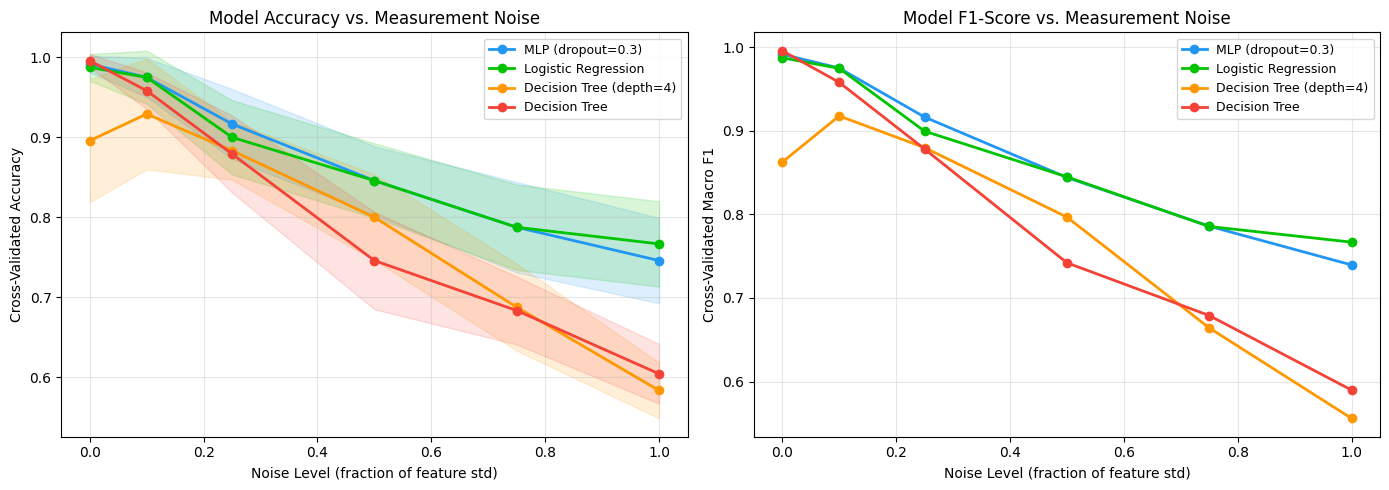

In [8]:
# ============================================================
# PLOT 1: NOISE ROBUSTNESS CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_order = ['mlp', 'logreg', 'dtree_constrained', 'dtree_full']
colors = {
    'mlp': '#2196F3',
    'logreg': '#00c400',
    'dtree_constrained': '#FF9800',
    'dtree_full': '#F44336'
}
labels = {
    'mlp': 'MLP (dropout=0.3)',
    'logreg': 'Logistic Regression',
    'dtree_constrained': 'Decision Tree (depth=4)',
    'dtree_full': 'Decision Tree'
}

for model_name in model_order:
    acc_means = [np.mean(all_results[n][model_name]['acc']) for n in noise_levels]
    acc_stds = [np.std(all_results[n][model_name]['acc']) for n in noise_levels]
    f1_means = [np.mean(all_results[n][model_name]['f1']) for n in noise_levels]

    axes[0].plot(noise_levels, acc_means, '-o', color=colors[model_name],
                label=labels[model_name], linewidth=2, markersize=6)
    axes[0].fill_between(noise_levels,
                         [m - s for m, s in zip(acc_means, acc_stds)],
                         [m + s for m, s in zip(acc_means, acc_stds)],
                         alpha=0.15, color=colors[model_name])
    axes[1].plot(noise_levels, f1_means, '-o', color=colors[model_name],
                 label=labels[model_name], linewidth=2, markersize=6)

axes[0].set_xlabel('Noise Level (fraction of feature std)')
axes[0].set_ylabel('Cross-Validated Accuracy')
axes[0].set_title('Model Accuracy vs. Measurement Noise')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Noise Level (fraction of feature std)')
axes[1].set_ylabel('Cross-Validated Macro F1')
axes[1].set_title('Model F1-Score vs. Measurement Noise')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<br>

### **4. Experiment 1: Results and Analysis**

At zero noise, all models perform well—the unconstrained decision tree leads at 99.6% accuracy, with the MLP close behind at 99.2% and logistic regression at 98.8%. As measurement noise increases, three distinct phases emerge.

At moderate noise levels (0.25-0.50), the MLP maintains a 1.7-4 point advantage over all baselines, indicating that its learned nonlinear representations are more robust to perturbation than sharp threshold-based splits. Under heavy noise (0.75-1.0), logistic regression edges ahead, suggesting that simpler linear decision boundaries are more resilient to extreme feature perturbation than the MLP's complex learned mappings.

The most striking finding is the decision tree collapse: the unconstrained tree drops from 99.6% to 60.4%—a 39-point degradation—as its sharp threshold splits become unreliable under measurement uncertainty. The constrained tree (depth=4) is weaker on clean data but degrades less catastrophically, suggesting that depth constraints partially mitigate noise sensitivity.

<br>

### **5. Experiment 2: Dropout Ablation**

The dropout ablation reveals that lighter regularization (0.1-0.3) consistently outperforms aggressive dropout (0.5), which increases variance without improving generalization on this dataset size. Dropout rates of 0.1 and 0.3 tie for best performance at 91.7% cross-validated accuracy under noise=0.25, while 0.5 drops to 90.0% with higher standard deviation.

In [9]:
# ============================================================
# EXPERIMENT 2: DROPOUT ABLATION
# ============================================================

dropout_rates = [0.1, 0.2, 0.3, 0.5]
dropout_results = []

skf_ablation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for dr in dropout_rates:
    print(f"\nDropout = {dr}")
    accs = []
    f1s = []

    for fold, (train_idx, test_idx) in enumerate(skf_ablation.split(X_numeric_raw, y_array)):
        # Same data prep as evaluate_models_cv, fixed noise=0.25
        X_num_train = add_gaussian_noise(
            X_numeric_raw[train_idx].copy(), 0.25, seed=fold
        )
        X_num_test = add_gaussian_noise(
            X_numeric_raw[test_idx].copy(), 0.25, seed=fold + 100
        )

        X_train_combined = np.hstack([X_num_train, X_categorical[train_idx]])
        X_test_combined = np.hstack([X_num_test, X_categorical[test_idx]])

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_combined)
        X_test_scaled = scaler.transform(X_test_combined)

        a, f = train_eval_mlp(
            X_train_scaled, y_array[train_idx],
            X_test_scaled, y_array[test_idx],
            dropout=dr, seed=42
        )
        accs.append(a)
        f1s.append(f)

    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    mean_f1 = np.mean(f1s)
    std_f1 = np.std(f1s)
    dropout_results.append((dr, mean_acc, std_acc, mean_f1, std_f1))
    print(f"  acc = {mean_acc:.3f} ± {std_acc:.3f}, f1 = {mean_f1:.3f} ± {std_f1:.3f}")


Dropout = 0.1
  acc = 0.917 ± 0.048, f1 = 0.916 ± 0.048

Dropout = 0.2
  acc = 0.912 ± 0.046, f1 = 0.912 ± 0.047

Dropout = 0.3
  acc = 0.917 ± 0.044, f1 = 0.916 ± 0.044

Dropout = 0.5
  acc = 0.900 ± 0.061, f1 = 0.899 ± 0.062


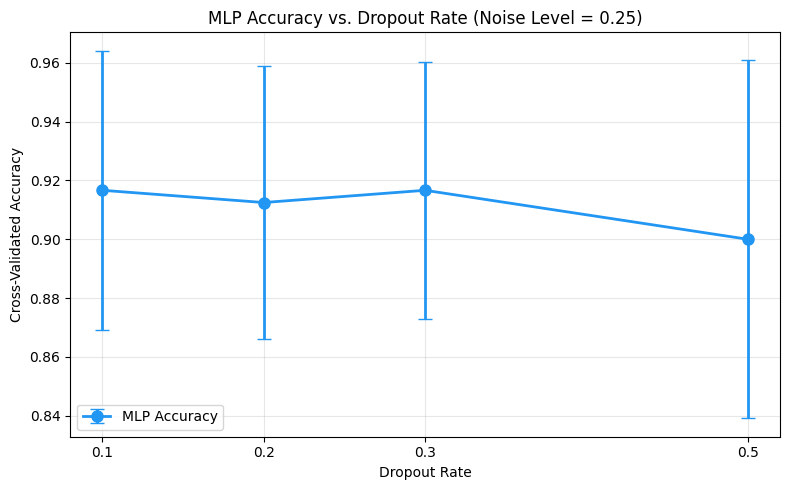

In [10]:
# ============================================================
# PLOT 2: DROPOUT ABLATION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

dr_vals = [r[0] for r in dropout_results]
acc_means = [r[1] for r in dropout_results]
acc_stds = [r[2] for r in dropout_results]

ax.errorbar(dr_vals, acc_means, yerr=acc_stds, fmt='-o', color='#2196F3',
            capsize=5, linewidth=2, markersize=8, label='MLP Accuracy')

ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Cross-Validated Accuracy')
ax.set_title('MLP Accuracy vs. Dropout Rate (Noise Level = 0.25)')
ax.set_xticks(dropout_rates)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

<br>

### **6. Representative Run: Diagnostics and Visualization**

A representative single-split run (70-15-15) is preserved for diagnostic visualization—training curves, classification report, and confusion matrix on clean data. This run is illustrative rather than evaluative; all reported performance metrics come from the cross-validated experiments above.

The confusion matrix shows near-perfect classification across all six star types, with minor confusion between White Dwarfs (class 2) and Main Sequence stars (class 3). These classes share overlapping temperature ranges (~7,000-25,000K) but are physically distinguished by radius—white dwarfs are extremely compact (R < 0.02 solar radii) while main sequence stars are substantially larger. Misclassification between these types suggests the model occasionally underweights the radius feature when noise perturbs the temperature signal.

Epoch 10: Train Loss=0.8978, Val Acc=0.8108
Epoch 20: Train Loss=0.5855, Val Acc=0.9459
Epoch 30: Train Loss=0.3715, Val Acc=0.9730
Epoch 40: Train Loss=0.3120, Val Acc=0.9730
Epoch 50: Train Loss=0.2190, Val Acc=1.0000


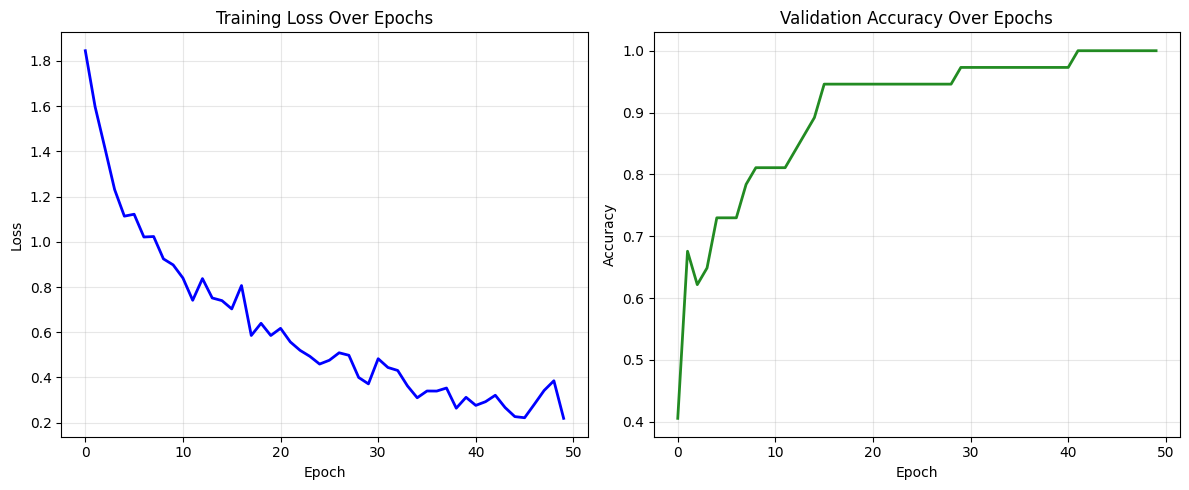


Representative Run — Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         6
           3       1.00      0.83      0.91         6
           4       0.86      1.00      0.92         6
           5       1.00      1.00      1.00         6

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.98      0.97      0.97        36

Test Accuracy: 0.9722


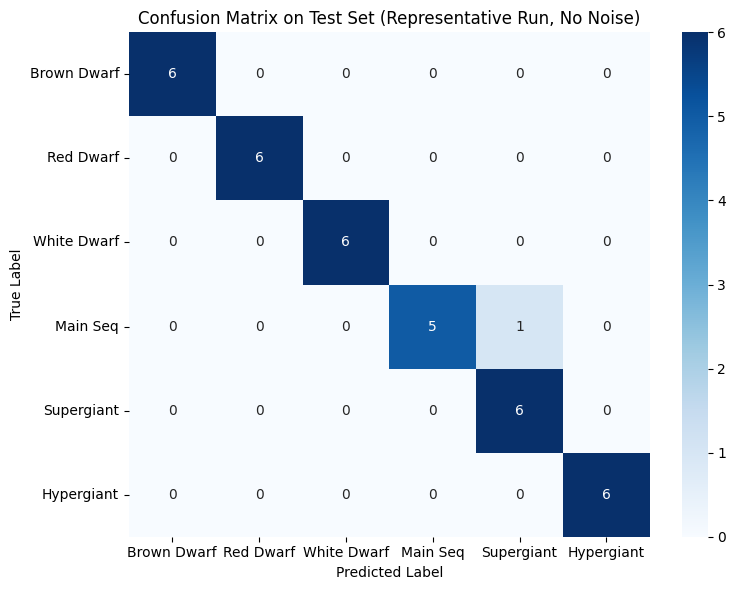


ALL EXPERIMENTS COMPLETE

Summary of noise sweep results:

  Noise = 0.0:
    MLP (dropout=0.3)             : acc = 0.992 ± 0.010, f1 = 0.992 ± 0.010
    Logistic Regression           : acc = 0.988 ± 0.017, f1 = 0.987 ± 0.017
    Decision Tree (depth=4)       : acc = 0.896 ± 0.077, f1 = 0.862 ± 0.104
    Decision Tree                 : acc = 0.996 ± 0.008, f1 = 0.996 ± 0.008

  Noise = 0.1:
    MLP (dropout=0.3)             : acc = 0.975 ± 0.024, f1 = 0.975 ± 0.024
    Logistic Regression           : acc = 0.975 ± 0.033, f1 = 0.975 ± 0.034
    Decision Tree (depth=4)       : acc = 0.929 ± 0.069, f1 = 0.918 ± 0.092
    Decision Tree                 : acc = 0.958 ± 0.023, f1 = 0.958 ± 0.023

  Noise = 0.25:
    MLP (dropout=0.3)             : acc = 0.917 ± 0.044, f1 = 0.916 ± 0.044
    Logistic Regression           : acc = 0.900 ± 0.046, f1 = 0.900 ± 0.047
    Decision Tree (depth=4)       : acc = 0.883 ± 0.036, f1 = 0.880 ± 0.040
    Decision Tree                 : acc = 0.879 ± 0.048,

In [11]:
# ============================================================
# REPRESENTATIVE RUN: TRAINING CURVES + CONFUSION MATRIX
# (preserved from original — generates report visuals)
# ============================================================

# Single 70-15-15 split for visualization purposes
X_full_raw = np.hstack([X_numeric_raw, X_categorical])
X_temp, X_test_rep, y_temp, y_test_rep = train_test_split(
    X_full_raw, y_array, test_size=0.15, stratify=y_array, random_state=42
)
X_train_rep, X_val_rep, y_train_rep, y_val_rep = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

scaler_rep = StandardScaler()
X_train_rep = scaler_rep.fit_transform(X_train_rep)
X_val_rep = scaler_rep.transform(X_val_rep)
X_test_rep = scaler_rep.transform(X_test_rep)

# Retrain MLP with tracking for curves
torch.manual_seed(42)

model_rep = nn.Sequential(
    nn.Linear(X_train_rep.shape[1], 64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.Dropout(0.3),
    nn.Linear(32, 6)
)
optimizer_rep = optim.Adam(model_rep.parameters(), lr=0.001)
criterion_rep = nn.CrossEntropyLoss()

X_train_t = torch.tensor(X_train_rep, dtype=torch.float32)
y_train_t = torch.tensor(y_train_rep, dtype=torch.long)
X_val_t = torch.tensor(X_val_rep, dtype=torch.float32)
y_val_t = torch.tensor(y_val_rep, dtype=torch.long)
X_test_t = torch.tensor(X_test_rep, dtype=torch.float32)
y_test_t = torch.tensor(y_test_rep, dtype=torch.long)

train_loader_rep = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True
)

train_losses = []
val_accuracies = []
best_val_acc = 0
best_model_state = None

for epoch in range(50):
    model_rep.train()
    total_loss = 0
    for X_batch, y_batch in train_loader_rep:
        optimizer_rep.zero_grad()
        outputs = model_rep(X_batch)
        loss = criterion_rep(outputs, y_batch)
        loss.backward()
        optimizer_rep.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_rep)
    train_losses.append(avg_loss)

    model_rep.eval()
    correct, total = 0, 0
    with torch.no_grad():
        preds = model_rep(X_val_t).argmax(dim=1)
        correct += (preds == y_val_t).sum().item()
        total += y_val_t.size(0)
    val_acc = correct / total
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in model_rep.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}: Train Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}")

model_rep.load_state_dict(best_model_state)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, color='#0000ff', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Epochs')
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_accuracies, color='#228b22', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
model_rep.eval()
with torch.no_grad():
    test_preds = model_rep(X_test_t).argmax(dim=1).numpy()

print("\nRepresentative Run — Test Classification Report:")
print(classification_report(y_test_rep, test_preds))

test_acc = accuracy_score(y_test_rep, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_rep, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
                         'Main Seq', 'Supergiant', 'Hypergiant'],
            yticklabels=['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
                         'Main Seq', 'Supergiant', 'Hypergiant'])
plt.title('Confusion Matrix on Test Set (Representative Run, No Noise)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("ALL EXPERIMENTS COMPLETE")
print("="*75)
print("\nSummary of noise sweep results:")
for noise in noise_levels:
    print(f"\n  Noise = {noise}:")
    for model_name in model_order:
        m = all_results[noise][model_name]
        print(f"    {labels[model_name]:30s}: "
              f"acc = {np.mean(m['acc']):.3f} ± {np.std(m['acc']):.3f}, "
              f"f1 = {np.mean(m['f1']):.3f} ± {np.std(m['f1']):.3f}")

print("\nSummary of dropout ablation (noise=0.25):")
for dr, acc_m, acc_s, f1_m, f1_s in dropout_results:
    print(f"  Dropout={dr}: acc = {acc_m:.3f} ± {acc_s:.3f}, f1 = {f1_m:.3f} ± {f1_s:.3f}")

<br>

### **7. Conclusion and Future Work**

This project investigated how different model classes respond to measurement noise on small scientific datasets, using stellar classification as a case study. The key finding is that peak accuracy on clean data is a misleading metric for model selection in scientific applications where measurement uncertainty is ubiquitous. The unconstrained decision tree achieved near-perfect accuracy (99.6%) on clean data—expected, since stellar types are largely defined by threshold-based physical relationships. However, this advantage collapsed under Gaussian noise, dropping 39 percentage points at maximum noise. The regularized MLP and logistic regression proved substantially more robust, with the MLP holding a narrow advantage at moderate noise levels most relevant to real astronomical observations.

#### **Key Takeaways:**
- Model selection for scientific applications should prioritize noise robustness over peak clean-data performance.

- Decision trees, despite their interpretability and clean-data accuracy, are poorly suited for noisy astronomical measurements due to sharp threshold sensitivity.

- Neural networks and linear models offer comparable robustness on small tabular datasets, with neural networks holding a slight edge at moderate noise levels.

- Regularization intensity should scale with dataset size—excessive dropout on small datasets suppresses signal more than it prevents overfitting.

#### **Future Work:**
- Incorporate astrophysical metadata such as parallax, variability indices, and metallicity to improve classification of spectrally adjacent types.

- Extend the noise model beyond Gaussian perturbation to include correlated measurement errors reflective of specific instrument characteristics.

- Explore semi-supervised approaches integrating synthetic labels with unlabeled real-world observations to bridge the gap between simulation and application.

- Experiment with transformer-based architectures for tabular data that may capture feature interactions more efficiently than MLPs on small datasets.